# Análise da Relação: Volatilidade vs Bootstrap Max Drawdown

Este notebook testa empiricamente a relação entre volatilidade e max drawdown obtido através de bootstrap usando o framework TimeSeries/MultiTimeSeries.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Import finpie classes
from finpie.data.timeseries import TimeSeries, TimeSeriesMetadata
from finpie.data.multitimeseries import MultiTimeSeries

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")


Using GPU: NVIDIA GeForce RTX 3090
GPU Memory: 25.8 GB
Libraries imported successfully!


## 1. Função para Gerar Time Series Sintéticas


In [2]:
def generate_synthetic_timeseries(volatility, n_periods=1000, mean_return=0.0, 
                                 distribution='normal', start_date='2020-01-01'):
    """
    Gera uma time series sintética com volatilidade específica
    
    Args:
        volatility: Volatilidade diária desejada
        n_periods: Número de períodos
        mean_return: Retorno médio diário
        distribution: 'normal', 'student_t', 'skewed_normal'
        start_date: Data inicial
    
    Returns:
        TimeSeries object
    """
    # Generate date range
    dates = pd.date_range(start=start_date, periods=n_periods, freq='D')
    
    # Generate returns based on distribution
    if distribution == 'normal':
        returns = np.random.normal(mean_return, volatility, n_periods)
    elif distribution == 'student_t':
        # Student-t with 5 degrees of freedom (fat tails)
        returns = stats.t.rvs(df=5, loc=mean_return, scale=volatility, size=n_periods)
    elif distribution == 'skewed_normal':
        # Skewed normal (negative skew for financial data)
        returns = stats.skewnorm.rvs(a=-2, loc=mean_return, scale=volatility, size=n_periods)
    else:
        raise ValueError("Distribution must be 'normal', 'student_t', or 'skewed_normal'")
    
    # Convert to cumulative PnL (starting from 0)
    cumulative_pnl = np.cumsum(returns)
    
    # Create DataFrame
    df = pd.DataFrame({
        'pnl': cumulative_pnl
    }, index=dates)
    
    # Create metadata
    metadata = TimeSeriesMetadata(
        name=f'synthetic_vol_{volatility:.4f}',
        symbol=f'SYN_VOL_{volatility:.4f}',
        source='synthetic',
        start_date=dates[0],
        end_date=dates[-1],
        frequency='D',
        currency='USD',
        additional_info={'target_volatility': volatility, 'distribution': distribution}
    )
    
    return TimeSeries(df, metadata)

# Test the function
test_ts = generate_synthetic_timeseries(volatility=1000, n_periods=252)
print(f"Generated test time series with {len(test_ts.data)} periods")
print(f"Actual volatility: {test_ts.volatility(method='absolute', annualized=False).iloc[0]:.4f}")


Generated test time series with 252 periods
Actual volatility: 1069.3116


## 2. Função para Análise Bootstrap


In [15]:
def bootstrap_analysis(timeseries, n_simulations=1000, percentiles=[1, 5, 25, 50, 75, 95, 99]):
    """
    Realiza análise bootstrap para uma time series específica
    
    Args:
        timeseries: TimeSeries object
        n_simulations: Número de simulações bootstrap
        percentiles: Percentis para análise
    
    Returns:
        dict com resultados da análise
    """
    # Generate bootstrap simulations
    simulated_portfolios = timeseries.generate_bootraped_timeseries(
        simulations=n_simulations, 
        method='absolute'
    )
    
    # Create MultiTimeSeries
    simulated_mts = MultiTimeSeries(simulated_portfolios)
    
    # Calculate max drawdowns for all simulations
    max_drawdowns = simulated_mts.max_drawdown(percentage=False)
    
    # Calculate statistics
    results = {
        'volatility': timeseries.volatility(method='absolute', annualized=False).iloc[0],
        'variance': timeseries.volatility(method='absolute', annualized=False).iloc[0] ** 2,
        'original_max_dd': timeseries.max_drawdown(percentage=False).iloc[0],
        'bootstrap_mean_max_dd': max_drawdowns.mean(),
        'bootstrap_std_max_dd': max_drawdowns.std(),
        'bootstrap_min_max_dd': max_drawdowns.min(),
        'bootstrap_max_max_dd': max_drawdowns.max(),
        'n_simulations': n_simulations
    }
    
    # Add percentiles
    for p in percentiles:
        results[f'bootstrap_p{p}_max_dd'] = np.percentile(max_drawdowns, p)
    
    # Store raw bootstrap results for further analysis
    results['raw_bootstrap_max_dds'] = max_drawdowns.values
    
    return results

# Test the bootstrap analysis
test_results = bootstrap_analysis(test_ts, n_simulations=100)
print("Bootstrap analysis test completed!")
print(f"Original Max DD: {test_results['original_max_dd']:.2f}")
print(f"Bootstrap Mean Max DD: {test_results['bootstrap_mean_max_dd']:.2f}")
print(f"Bootstrap P5 Max DD: {test_results['bootstrap_p5_max_dd']:.2f}")


Bootstrap analysis test completed!
Original Max DD: -18671.83
Bootstrap Mean Max DD: -21623.72
Bootstrap P5 Max DD: -29055.89


## 3. Experimento Principal: Múltiplas Volatilidades


In [16]:
def run_volatility_experiment(volatility_range, n_periods=1000, n_simulations=500, 
                             distributions=['normal'], n_replications=3):
    """
    Executa experimento completo testando múltiplas volatilidades
    
    Args:
        volatility_range: Lista de volatilidades para testar
        n_periods: Número de períodos por time series
        n_simulations: Número de simulações bootstrap por time series
        distributions: Lista de distribuições para testar
        n_replications: Número de replicações por volatilidade
    
    Returns:
        DataFrame com resultados completos
    """
    results = []
    total_experiments = len(volatility_range) * len(distributions) * n_replications
    current_experiment = 0
    
    print(f"Starting experiment with {total_experiments} total runs...")
    
    for distribution in distributions:
        for vol in volatility_range:
            for replication in range(n_replications):
                current_experiment += 1
                
                if current_experiment % 5 == 0:
                    print(f"Progress: {current_experiment}/{total_experiments} "
                          f"({100*current_experiment/total_experiments:.1f}%)")
                
                try:
                    # Generate synthetic time series
                    ts = generate_synthetic_timeseries(
                        volatility=vol, 
                        n_periods=n_periods,
                        distribution=distribution
                    )
                    
                    # Perform bootstrap analysis
                    bootstrap_results = bootstrap_analysis(ts, n_simulations=n_simulations)
                    
                    # Add experiment metadata
                    bootstrap_results.update({
                        'target_volatility': vol,
                        'distribution': distribution,
                        'replication': replication,
                        'n_periods': n_periods
                    })
                    
                    # Remove raw data to save memory
                    bootstrap_results.pop('raw_bootstrap_max_dds', None)
                    
                    results.append(bootstrap_results)
                    
                except Exception as e:
                    print(f"Error in experiment {current_experiment}: {e}")
                    continue
    
    print("Experiment completed!")
    return pd.DataFrame(results)

# Define volatility range for experiment
volatility_range = [100, 200, 500, 750, 1000, 1500, 2000, 3000, 5000, 7500, 10000]

print(f"Will test volatilities: {volatility_range}")
print("Starting main experiment...")


Will test volatilities: [100, 200, 500, 750, 1000, 1500, 2000, 3000, 5000, 7500, 10000]
Starting main experiment...


In [17]:
experiment_results

,volatility,variance,original_max_dd,bootstrap_mean_max_dd,bootstrap_std_max_dd,bootstrap_min_max_dd,bootstrap_max_max_dd,n_simulations,bootstrap_p5_max_dd,bootstrap_p25_max_dd,bootstrap_p50_max_dd,bootstrap_p75_max_dd,bootstrap_p95_max_dd,bootstrap_p99_max_dd,target_volatility,distribution,replication,n_periods
0,97.665840,9.538616e+03,-2148.102570,-3014.299519,875.393939,-6994.642831,-1543.808552,100,-4623.319907,-3435.673396,-2892.667079,-2406.844436,-1975.201076,-1563.016008,100,normal,0,1000
1,102.088717,1.042211e+04,-3714.235553,-3387.587775,767.918000,-5467.039888,-2007.951107,100,-4680.986565,-3886.842371,-3335.875229,-2806.073947,-2247.200594,-2077.057637,100,normal,1,1000
2,196.259357,3.851774e+04,-7874.382289,-7010.812213,1705.020000,-11626.729897,-3650.527608,100,-10036.121980,-8194.262951,-6828.476601,-5657.626429,-4628.556612,-4160.162552,200,normal,0,1000
3,207.020905,4.285766e+04,-4703.901244,-6113.015291,1608.801836,-10716.920180,-3712.346376,100,-9311.033879,-6926.800857,-5877.575770,-4906.396466,-4246.862263,-3758.224861,200,normal,1,1000
4,501.065032,2.510662e+05,-11892.354707,-14106.543931,3307.513550,-25581.767746,-7275.223460,100,-19373.531706,-15959.711611,-13950.785387,-12096.067559,-9540.486500,-8019.148656,500,normal,0,1000
5,518.862391,2.692182e+05,-32554.146365,-34811.254123,4041.207792,-49356.992643,-27932.702005,100,-40622.369773,-37269.666400,-34437.321019,-32183.323329,-29317.532595,-28566.871678,500,normal,1,1000
6,730.845106,5.341346e+05,-45218.999754,-40669.789474,7669.125312,-65574.059605,-26906.422816,100,-54558.011126,-43933.185273,-38947.919250,-35338.455624,-31270.247481,-29092.169934,750,normal,0,1000
7,736.569932,5.425353e+05,-30541.608259,-43383.414764,6495.736182,-56920.735760,-30053.692269,100,-55010.023557,-47413.592128,-42943.675036,-38551.983287,-34137.890963,-30716.505038,750,normal,1,1000
8,1028.853959,1.058540e+06,-52165.327338,-51566.478358,9570.254704,-78877.343158,-31199.790344,100,-70827.866141,-56560.008500,-51248.376964,-44941.623176,-37430.956356,-34514.871450,1000,normal,0,1000
9,964.346570,9.299643e+05,-18027.556660,-22566.651758,5501.796479,-39192.953841,-12003.653234,100,-33985.422445,-24755.591544,-21766.634488,-18978.214533,-15326.026496,-12426.946192,1000,normal,1,1000


In [18]:
# Run the main experiment
experiment_results = run_volatility_experiment(
    volatility_range=volatility_range,
    n_periods=1000,
    n_simulations=100,  # Reduced for faster execution
    distributions=['normal'],
    n_replications=2    # Reduced for faster execution
)

print(f"\nExperiment completed! Generated {len(experiment_results)} data points.")
print("\nSample results:")
print(experiment_results[['target_volatility', 'volatility', 'bootstrap_mean_max_dd', 
                         'bootstrap_p5_max_dd', 'bootstrap_p1_max_dd']].head(10))


Starting experiment with 22 total runs...
Progress: 5/22 (22.7%)
Progress: 10/22 (45.5%)
Progress: 15/22 (68.2%)
Progress: 20/22 (90.9%)
Experiment completed!

Experiment completed! Generated 22 data points.

Sample results:
   target_volatility   volatility  bootstrap_mean_max_dd  bootstrap_p5_max_dd  \
0                100   102.052874           -2630.905578         -3871.934762   
1                100   102.148828           -4245.285526         -6019.838229   
2                200   199.089931           -6577.571051         -9392.340275   
3                200   203.656808          -10045.463486        -12726.181466   
4                500   509.037908          -16437.650488        -24268.599882   
5                500   506.167857          -38118.092301        -43434.619067   
6                750   760.617824          -48545.201302        -60713.885556   
7                750   748.157280          -20651.620390        -29764.119202   
8               1000  1002.664096          -27

## 4. Análise de Correlação e Regressão


In [21]:
def analyze_correlations(results_df):
    """
    Analisa correlações entre volatilidade e métricas bootstrap
    """
    # Calculate correlations
    metrics_to_analyze = [
        'bootstrap_mean_max_dd',
        'bootstrap_p50_max_dd', 
        'bootstrap_p5_max_dd',
        'bootstrap_p1_max_dd',
        'original_max_dd'
    ]
    
    correlations = {}
    
    for metric in metrics_to_analyze:
        # Correlation with volatility
        corr_vol = results_df['volatility'].corr(results_df[metric])
        # Correlation with variance
        corr_var = results_df['variance'].corr(results_df[metric])
        
        correlations[f'{metric}_vs_volatility'] = corr_vol
        correlations[f'{metric}_vs_variance'] = corr_var
    
    return correlations

def perform_regression_analysis(results_df):
    """
    Realiza análise de regressão para diferentes métricas
    """
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import r2_score
    
    regression_results = {}
    
    metrics = ['bootstrap_mean_max_dd', 'bootstrap_p5_max_dd', 'bootstrap_p1_max_dd']
    
    for metric in metrics:
        # Linear regression: Y = a + b*X
        X_vol = results_df['volatility'].values.reshape(-1, 1)
        X_var = results_df['variance'].values.reshape(-1, 1)
        y = results_df[metric].values
        
        # Volatility regression
        reg_vol = LinearRegression().fit(X_vol, y)
        y_pred_vol = reg_vol.predict(X_vol)
        r2_vol = r2_score(y, y_pred_vol)
        
        # Variance regression
        reg_var = LinearRegression().fit(X_var, y)
        y_pred_var = reg_var.predict(X_var)
        r2_var = r2_score(y, y_pred_var)
        
        regression_results[metric] = {
            'volatility_r2': r2_vol,
            'volatility_coef': reg_vol.coef_[0],
            'volatility_intercept': reg_vol.intercept_,
            'variance_r2': r2_var,
            'variance_coef': reg_var.coef_[0],
            'variance_intercept': reg_var.intercept_
        }
    
    return regression_results

# Perform correlation analysis
correlations = analyze_correlations(experiment_results)
regressions = perform_regression_analysis(experiment_results)

print("=" * 60)
print("CORRELATION ANALYSIS")
print("=" * 60)
for key, value in correlations.items():
    print(f"{key:35}: {value:.4f}")

print("\n" + "=" * 60)
print("REGRESSION ANALYSIS (R² VALUES)")
print("=" * 60)
for metric, results in regressions.items():
    print(f"\n{metric}:")
    print(f"  Volatility R²: {results['volatility_r2']:.4f}")
    print(f"  Variance R²:   {results['variance_r2']:.4f}")
    print(f"  Vol coefficient: {results['volatility_coef']:.6f}")
    print(f"  Vol intercept:   {results['volatility_intercept']:.2f}")


CORRELATION ANALYSIS
bootstrap_mean_max_dd_vs_volatility: -0.9178
bootstrap_mean_max_dd_vs_variance  : -0.8628
bootstrap_p50_max_dd_vs_volatility : -0.9119
bootstrap_p50_max_dd_vs_variance   : -0.8561
bootstrap_p5_max_dd_vs_volatility  : -0.9489
bootstrap_p5_max_dd_vs_variance    : -0.8998
bootstrap_p1_max_dd_vs_volatility  : -0.9477
bootstrap_p1_max_dd_vs_variance    : -0.8947
original_max_dd_vs_volatility      : -0.8945
original_max_dd_vs_variance        : -0.8500

REGRESSION ANALYSIS (R² VALUES)

bootstrap_mean_max_dd:
  Volatility R²: 0.8423
  Variance R²:   0.7444
  Vol coefficient: -38.320169
  Vol intercept:   -3612.65

bootstrap_p5_max_dd:
  Volatility R²: 0.9004
  Variance R²:   0.8096
  Vol coefficient: -53.159219
  Vol intercept:   -3241.75

bootstrap_p1_max_dd:
  Volatility R²: 0.8981
  Variance R²:   0.8005
  Vol coefficient: -59.919256
  Vol intercept:   -4946.10


## 5. Visualizações


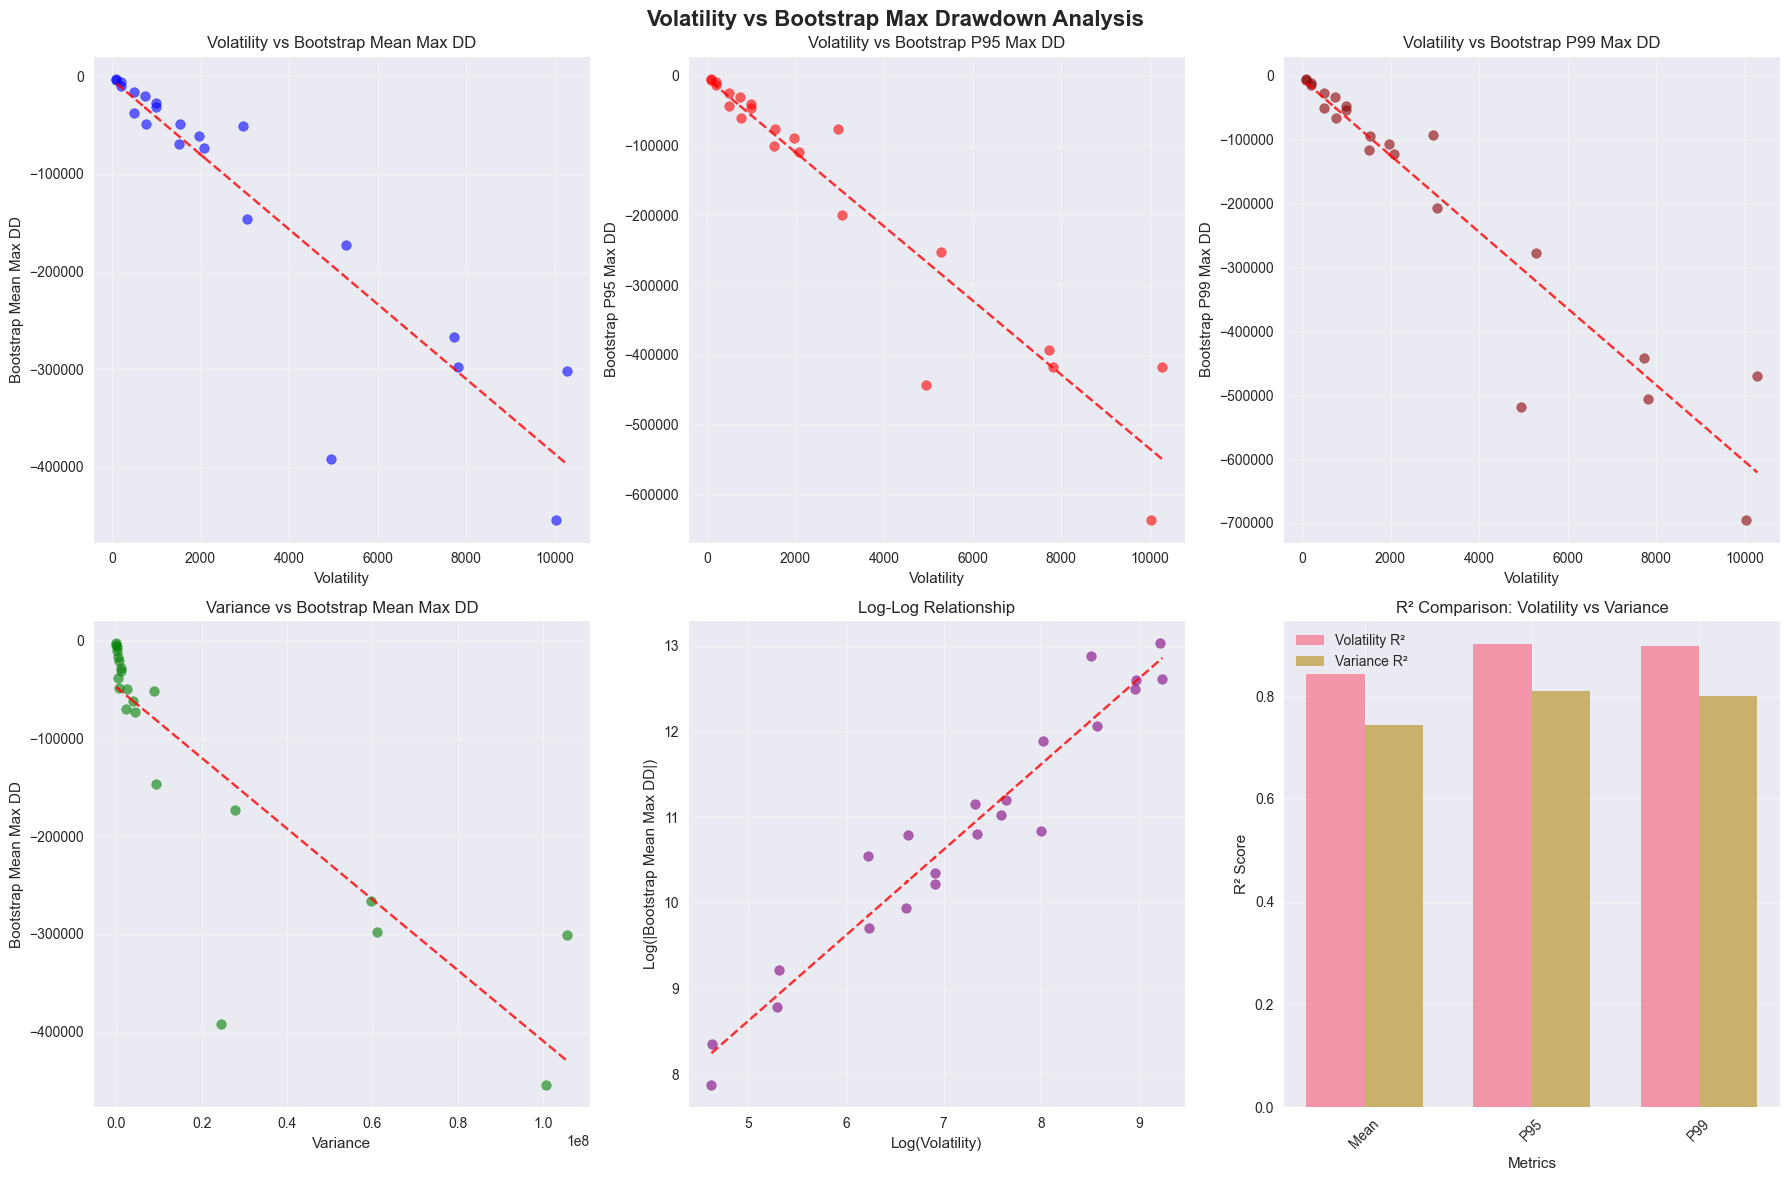

In [22]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Volatility vs Bootstrap Max Drawdown Analysis', fontsize=16, fontweight='bold')

# Plot 1: Volatility vs Bootstrap Mean Max DD
axes[0, 0].scatter(experiment_results['volatility'], experiment_results['bootstrap_mean_max_dd'], 
                   alpha=0.6, c='blue')
axes[0, 0].set_xlabel('Volatility')
axes[0, 0].set_ylabel('Bootstrap Mean Max DD')
axes[0, 0].set_title('Volatility vs Bootstrap Mean Max DD')
axes[0, 0].grid(True, alpha=0.3)

# Add regression line
z = np.polyfit(experiment_results['volatility'], experiment_results['bootstrap_mean_max_dd'], 1)
p = np.poly1d(z)
axes[0, 0].plot(experiment_results['volatility'], p(experiment_results['volatility']), "r--", alpha=0.8)

# Plot 2: Volatility vs Bootstrap P95 Max DD
axes[0, 1].scatter(experiment_results['volatility'], experiment_results['bootstrap_p5_max_dd'], 
                   alpha=0.6, c='red')
axes[0, 1].set_xlabel('Volatility')
axes[0, 1].set_ylabel('Bootstrap P95 Max DD')
axes[0, 1].set_title('Volatility vs Bootstrap P95 Max DD')
axes[0, 1].grid(True, alpha=0.3)

z = np.polyfit(experiment_results['volatility'], experiment_results['bootstrap_p5_max_dd'], 1)
p = np.poly1d(z)
axes[0, 1].plot(experiment_results['volatility'], p(experiment_results['volatility']), "r--", alpha=0.8)

# Plot 3: Volatility vs Bootstrap P99 Max DD
axes[0, 2].scatter(experiment_results['volatility'], experiment_results['bootstrap_p1_max_dd'], 
                   alpha=0.6, c='darkred')
axes[0, 2].set_xlabel('Volatility')
axes[0, 2].set_ylabel('Bootstrap P99 Max DD')
axes[0, 2].set_title('Volatility vs Bootstrap P99 Max DD')
axes[0, 2].grid(True, alpha=0.3)

z = np.polyfit(experiment_results['volatility'], experiment_results['bootstrap_p1_max_dd'], 1)
p = np.poly1d(z)
axes[0, 2].plot(experiment_results['volatility'], p(experiment_results['volatility']), "r--", alpha=0.8)

# Plot 4: Variance vs Bootstrap Mean Max DD
axes[1, 0].scatter(experiment_results['variance'], experiment_results['bootstrap_mean_max_dd'], 
                   alpha=0.6, c='green')
axes[1, 0].set_xlabel('Variance')
axes[1, 0].set_ylabel('Bootstrap Mean Max DD')
axes[1, 0].set_title('Variance vs Bootstrap Mean Max DD')
axes[1, 0].grid(True, alpha=0.3)

z = np.polyfit(experiment_results['variance'], experiment_results['bootstrap_mean_max_dd'], 1)
p = np.poly1d(z)
axes[1, 0].plot(experiment_results['variance'], p(experiment_results['variance']), "r--", alpha=0.8)

# Plot 5: Log-Log relationship
log_vol = np.log(experiment_results['volatility'])
log_dd = np.log(-experiment_results['bootstrap_mean_max_dd'])  # Use absolute values for log

axes[1, 1].scatter(log_vol, log_dd, alpha=0.6, c='purple')
axes[1, 1].set_xlabel('Log(Volatility)')
axes[1, 1].set_ylabel('Log(|Bootstrap Mean Max DD|)')
axes[1, 1].set_title('Log-Log Relationship')
axes[1, 1].grid(True, alpha=0.3)

z = np.polyfit(log_vol, log_dd, 1)
p = np.poly1d(z)
axes[1, 1].plot(log_vol, p(log_vol), "r--", alpha=0.8)

# Plot 6: R² comparison
metrics = ['bootstrap_mean_max_dd', 'bootstrap_p5_max_dd', 'bootstrap_p1_max_dd']
vol_r2s = [regressions[metric]['volatility_r2'] for metric in metrics]
var_r2s = [regressions[metric]['variance_r2'] for metric in metrics]

x = np.arange(len(metrics))
width = 0.35

axes[1, 2].bar(x - width/2, vol_r2s, width, label='Volatility R²', alpha=0.7)
axes[1, 2].bar(x + width/2, var_r2s, width, label='Variance R²', alpha=0.7)

axes[1, 2].set_xlabel('Metrics')
axes[1, 2].set_ylabel('R² Score')
axes[1, 2].set_title('R² Comparison: Volatility vs Variance')
axes[1, 2].set_xticks(x)
axes[1, 2].set_xticklabels(['Mean', 'P95', 'P99'], rotation=45)
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
